<a href="https://colab.research.google.com/github/simone-cappelletti/ai-sample-projects-library/blob/main/VisionTech_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Riconoscimento di animali per auto a guida autonoma

**VisionTech Solutions** vuole sviluppare un sistema di riconoscimento automatico delle immagini per distinguere tra veicoli e animali, con l'obiettivo di ottimizzare le operazioni di monitoraggio della fauna nelle aree urbane, evitando incidenti stradali e proteggendo sia gli animali che i veicoli.

---
**Dettagli del progetto**

1. Implementazione del modello
    1. **Dataset**: Utilizzo del dataset [CIFAR-10](https://cave.cs.toronto.edu/kriz/cifar.html), contenente migliaia di immagini etichettate in varie categorie, inclusi veicoli e animali.
    2. **Algoritmo**: Implementazione di una rete neurale convoluzionale (CNN) per l'analisi e la classificazione delle immagini.
    3. **Output**: Il sistema classificherà correttamente ogni immagine come veicolo o animale.

2. Valutazione del modello
    1. **Accuratezza**: Proporzione di immagini classificate correttamente rispetto al totale.
    2. **Precisione**: Qualità delle predizioni positive, indicando la proporzione di immagini correttamente identificate.

3. Analisi dei Risultati
    - Identificazione di eventuali pattern di errore.
    - Valutazione delle categorie di immagini confuse sistematicamente.
    - Esame delle immagini errate e riflessione su possibili migliorie al modello.

4. Risultato Finale
    - Presentazione completa della rete neurale convoluzionale e delle sue capacità di discriminazione tra veicoli e animali.
    - Discussione dettagliata delle metriche utilizzate e un'analisi critica delle prestazioni e limitazioni del modello.

## 1. Implementazione del modello

Essendo CIFAR-10 un dataset "standard" ed ampiamente conosciuto sappiamo già dalla documentazione ufficiale che:
- Abbiamo 60k immagini a colori 32x32 divise in 10 classi, con 6k immagini per classe.
- Le 60k immagini sono divise in 50k immagini di train e 10k immagini di test.
- Le immagini di train sono organizzate in 5 batch da 10k immagini l'uno, mentre le immagini di test sono organizzate in un singolo batch da 10k di immagini.
- Il batch di test contiene 1k immagini selezionate in modo casuale da ciascuna classe mentre i batch di train contengono le immagini rimanenti in ordine casuale quindi alcuni di essi potrebbero contenere un numero maggiore di immagini di una classe rispetto ad un’altra.

Pertanto tra le prime conclusioni e considerazioni da poter fare abbiamo che:
- Il dataset è perfettamente bilanciato.
- Il dataset è ben fornito e sufficientemente grande per il nostro scopo, possiamo dunque escludere almeno nella fase iniziale eventuali strategie di *data augmentation*.
- Non sono interessato a tenere divisi i 5 batch di immagini di train, piuttosto preferisco unire tutti i batch di train in un'unico batch da 50k immagini da cui ricavare due sets train e validation (oltre al test). In realtà ho notato che il metodo [tf.keras.datasets.cifar10.load_data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar10/load_data) presente in Keras e che utilizzeremo per importare il dataset ritorna un'unico batch di immagini per il set di train.
- Potremmo voler fare un'upscaling delle immagini da `32x32` a `96x96` oppure anche `128x128` per sfruttare meglio i filtri della parte convoluzionale della rete che costruiremo.

Cominciamo importando il dataset per poi eseguire una breve EDA.

In [ ]:
# Imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models, optimizers, metrics
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.backend import clear_session
from tensorflow.keras.callbacks import EarlyStopping, Callback

In [ ]:
# Constants
CLASSES = [
  "airplane",   # 0
  "automobile", # 1
  "bird",       # 2
  "cat",        # 3
  "deer",       # 4
  "dog",        # 5
  "frog",       # 6
  "horse",      # 7
  "ship",       # 8
  "truck",      # 9
]

VEHICLE_CLASSES = {
  0, # airplane
  1, # automobile
  8, # ship
  9, # truck
}

ANIMAL_CLASSES = {
  2, # bird
  3, # cat
  4, # deer
  5, # dog
  6, # frog
  7, # horse
}

IMG_SIZE = 32 # Image size
EPOCHS = 10 # Number of epochs
BATCH_SIZE = 64 # Batch size
LAYERS_TO_FINE_TUNE = 10 # Number of layers to fine-tune
RANDOM_STATE = 0 # Random state

In [ ]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1257s 7us/step


Visualizziamo qualche immagine e verifichiamo giusto per scrupolo alcuni dettagli come:
- Il tipo delle immagini.
- Le shape di immagini ed etichette che mi aspetto essere rispettivamente `(50000, 32, 32, 3)` e `(50000, 1)`.
- Il range di valori presenti per le etichette che mi aspetto essere compreso e completo tra `0-9`.
- Valore minimo e massimo dei pixel che mi aspetto essere rispettivamente `0` e `255`.

Tipo dati immagini: uint8
Formato immagini train: (50000, 32, 32, 3)
Formato etichette train: (50000, 1)
Valori etichette train: [0 1 2 3 4 5 6 7 8 9]
Valore minimo pixel: 0
Valore massimo pixel: 255


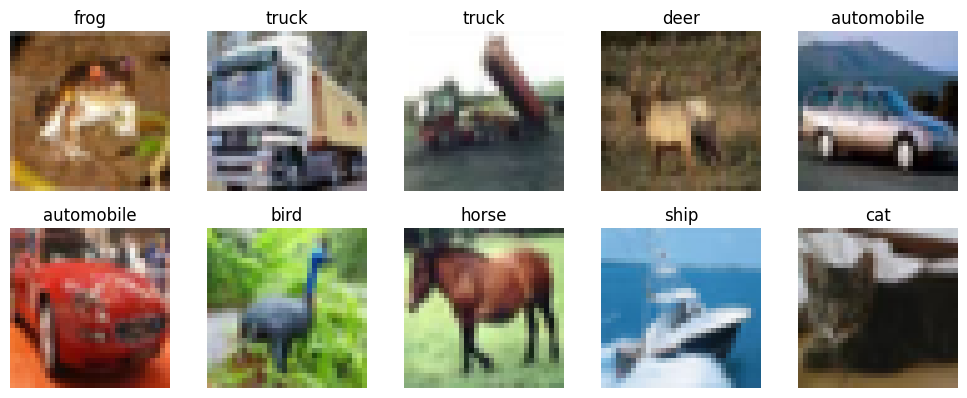

In [ ]:
print("Tipo dati immagini:", x_train_raw.dtype)

print("Formato immagini train:", x_train_raw.shape)
print("Formato etichette train:", y_train_raw.shape)

print("Valori etichette train:", np.unique(y_train_raw))

print("Valore minimo pixel:", x_train_raw.min())
print("Valore massimo pixel:", x_train_raw.max())

plt.figure(figsize=(10, 10))

for i in range(10):

  plt.subplot(5, 5, i + 1)
  plt.imshow(x_train_raw[i])
  plt.title(CLASSES[y_train_raw[i, 0]])
  plt.axis("off")

plt.tight_layout()
plt.show()

Non notiamo nulla di strano e non ci spingiamo oltre perché come abbiamo detto si tratta di un dataset già conosciuto ed ampiamente utilizzato quindi non avrebbe molto senso.

Proseguiamo definendo la funzione `load_cifar10_binary` al fine di:
- Eseguire il flatten delle etichette semplicemente per comodità e per lavorare con array monodimensionali.
- Eseguire il mapping tra le 10 classi presenti nel dataset CIFAR-10 verso le nostre 2 classi richieste.
- Eseguire il resizing da `32x32` a `96x96` ed il pre-processing delle immagini per **MobileNetV2** che come vedremo sarà la rete di base dalla quale partire.
- Creare lo split dei dataset per train e validation.

In [ ]:
def load_cifar10_binary(test_size = .3, random_state = RANDOM_STATE, img_size = IMG_SIZE):

  # Labels flattening
  y_train_flat = y_train_raw.flatten()
  y_test_flat = y_test_raw.flatten()

  # Binary mapping
  y_train_binary = np.where(np.isin(y_train_flat, list(ANIMAL_CLASSES)), 1, 0)
  y_test_binary = np.where(np.isin(y_test_flat, list(ANIMAL_CLASSES)), 1, 0)

  # Resizing for MobileNetV2
  x_train_tf = tf.image.resize(tf.cast(x_train_raw, tf.float32), (img_size, img_size))
  x_test_tf = tf.image.resize(tf.cast(x_test_raw, tf.float32), (img_size, img_size))

  # Pre-processing for MobileNetV2
  x_train_prep = preprocess_input(x_train_tf)
  x_test_prep = preprocess_input(x_test_tf)

  x_train_prep = x_train_prep.numpy()
  x_test_prep = x_test_prep.numpy()

  # Train/validation split
  x_train, x_val, y_train, y_val, y_train_flat_split, y_val_flat = train_test_split(
    x_train_prep,
    y_train_binary,
    y_train_flat,
    test_size = test_size,
    random_state = random_state,
    stratify = y_train_binary
  )

  return (
    x_train,
    y_train,
    y_train_flat_split,
    x_val,
    y_val,
    y_val_flat,
    x_test_prep,
    y_test_binary,
    y_test_flat
  )

(
  x_train,
  y_train,
  y_train_flat,
  x_val,
  y_val,
  y_val_flat,
  x_test,
  y_test,
  y_test_flat
) = load_cifar10_binary()

print("Formato immagini train:", x_train.shape)
print("Formato immagini validation:", x_val.shape)
print("Formato immagini test:", x_test.shape)

print()

print("Formato etichette train (binario):", y_train.shape)
print("Formato etichette validation (binario):", y_val.shape)
print("Formato etichette test (binario):", y_test.shape)

print()

print("Prime 10 etichette originali (train):", y_train_flat[:10])
print("Prime 10 etichette binarie (train):", y_train[:10])
print("Prime 10 etichette originali (validation):", y_val_flat[:10])
print("Prime 10 etichette binarie (validation):", y_val[:10])
print("Prime 10 etichette originali (test):", y_test_flat[:10])
print("Prime 10 etichette binarie (test):", y_test[:10])

print()

print("Valori unici etichette binarie in train:", np.unique(y_train))
print("Valori unici etichette binarie in validation:", np.unique(y_val))
print("Valori unici etichette binarie in test:", np.unique(y_test))

print()

print("Normalizzazione train - min:", x_train.min(), "| max:", x_train.max())
print("Normalizzazione validation - min:", x_val.min(), "| max:", x_val.max())
print("Normalizzazione test - min:", x_test.min(), "| max:", x_test.max())

Formato immagini train: (35000, 32, 32, 3)
Formato immagini validation: (15000, 32, 32, 3)
Formato immagini test: (10000, 32, 32, 3)

Formato etichette train (binario): (35000,)
Formato etichette validation (binario): (15000,)
Formato etichette test (binario): (10000,)

Prime 10 etichette originali (train): [7 3 6 5 7 3 8 2 8 2]
Prime 10 etichette binarie (train): [1 1 1 1 1 1 0 1 0 1]
Prime 10 etichette originali (validation): [9 1 6 1 4 9 0 3 2 3]
Prime 10 etichette binarie (validation): [0 0 1 0 1 0 0 1 1 1]
Prime 10 etichette originali (test): [3 8 8 0 6 6 1 6 3 1]
Prime 10 etichette binarie (test): [1 0 0 0 1 1 0 1 1 0]

Valori unici etichette binarie in train: [0 1]
Valori unici etichette binarie in validation: [0 1]
Valori unici etichette binarie in test: [0 1]

Normalizzazione train - min: -1.0 | max: 1.0
Normalizzazione validation - min: -1.0 | max: 1.0
Normalizzazione test - min: -1.0 | max: 1.0


**NOTA**

Purtroppo il resizing da `32x32` a `96x96` sembra saturare la RAM del notebook quindi al momento lasciamo il formato originale `32x32`.

Passiamo alla creazione del modello.

Come già accennato non partiamo da zero, bensì sfruttiamo il *transfer learning* e prendiamo come base la rete **MobileNetV2** addestrata sul noto dataset **[ImageNet](https://www.image-net.org/)**. Scegliamo questa rete semplicemente perché è abbastanza leggera pur offrendo buone performance e supporta la dimensione delle nostre immagini `32x32`, pur permettendo anche un'upscaling ad esempio a `96x96` ed evitando così di avere feature map molto piccole sin dai primi strati e sfruttare meglio i filtri.

In [ ]:
def build_model(img_size = IMG_SIZE, layers_to_fine_tune = LAYERS_TO_FINE_TUNE):

  clear_session()

  # Base model
  base_model = MobileNetV2(
    include_top = False,
    weights = "imagenet",
    input_shape = (img_size, img_size, 3)
  )

  # Base model's layers fine-tuning
  if(LAYERS_TO_FINE_TUNE <= 0):
    base_model.trainable = False
  else:
    base_model.trainable = True

    fine_tune_from = max(0, len(base_model.layers) - LAYERS_TO_FINE_TUNE)

    print("Numero di layer totale:", len(base_model.layers))
    print("Fine tuning dal layer:", fine_tune_from)

    for layer in base_model.layers[:fine_tune_from]:
      layer.trainable = False

    for layer in base_model.layers[fine_tune_from:]:
      if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

  # Additional layers
  inputs = layers.Input(shape=(img_size, img_size, 3))

  x = base_model(inputs, training = False)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dropout(0.2)(x)

  outputs = layers.Dense(1, activation = "sigmoid")(x)

  model = models.Model(
    inputs = inputs,
    outputs = outputs,
    name = "mobilenet_vehicle_animal"
  )

  model.compile(
    optimizer = optimizers.Adam(learning_rate = 1e-4),
    loss = "binary_crossentropy",
    metrics = ["accuracy", metrics.Precision(name = "precision")]
  )

  return model

model = build_model()
model.summary()

/tmp/ipykernel_2213/2022379710.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Numero di layer totale: 154
Fine tuning dal layer: 144


Model: "mobilenet_vehicle_animal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 726,721 (2.77 MB)

 Non-trainable params: 1,532,544 (5.85 MB)

Per quanto riguarda la creazione del modello:
- Modello base:
    - Come già accennato partiamo da **MobileNetV2** come base.
    - Escludiamo il classificatore originale tramite `include_top=False`. Manteniamo così solo la parte convoluzionale e di feature extraction.
    - Sfruttiamo i pesi di **ImageNet** tramite `weights="imagenet"` per il transfer learning.
    - Facciamo il *freezing* dell'addestramento per alcuni dei layers già presenti e addestriamo solo la quantità di layers da noi stabilita, oltre ai nuovi layers ovviamente.
- Layers, a quelli già presenti aggiungiamo:
    - Layer di input.
    - Layer di **pooling**.
    - Layer di **dropout**.
    - Layer di output denso con *sigmoide* per classificazione binaria.
- Configurazione modello:
    - **Adam** come ottimizzatore.
    - Loss function `binary_crossentropy` per il task di classificazione binaria.
    - `Accuracy` e `Precision` come metriche.

Ora proseguiamo con il training del modello:

In [ ]:
# Early stopping callback
early_stopping = EarlyStopping(
  monitor = "val_loss",
  patience = 3,
  min_delta = 1e-2,
  mode = "min",
  restore_best_weights = True,
  verbose = 1
)

# Console logging callback
class ConsoleLogger(Callback):

  def on_epoch_end(self, epoch, logs=None):

    logs = logs or {}
    loss = logs.get("loss")
    acc = logs.get("accuracy")
    prec = logs.get("precision")
    val_loss = logs.get("val_loss")
    val_acc = logs.get("val_accuracy")
    val_prec = logs.get("val_precision")

    print(
      f"\nEpoch {epoch + 1} ended - "
      f"loss: {loss:.4f} - acc: {acc:.4f} - prec: {prec:.4f} | "
      f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - val_prec: {val_prec:.4f}"
    )

console_logger = ConsoleLogger()

In [ ]:
# Training
history = model.fit(
  x_train,
  y_train,
  validation_data = (x_val, y_val),
  epochs = EPOCHS,
  batch_size = BATCH_SIZE,
  callbacks = [early_stopping, console_logger]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7948 - loss: 0.4273 - precision: 0.8074
Epoch 1 ended - loss: 0.3501 - acc: 0.8450 - prec: 0.8561 | val_loss: 0.2556 - val_acc: 0.8959 - val_prec: 0.8938
547/547 ━━━━━━━━━━━━━━━━━━━━ 52s 88ms/step - accuracy: 0.8450 - loss: 0.3501 - precision: 0.8561 - val_accuracy: 0.8959 - val_loss: 0.2556 - val_precision: 0.8938
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8853 - loss: 0.2810 - precision: 0.9001
Epoch 2 ended - loss: 0.2814 - acc: 0.8849 - prec: 0.8992 | val_loss: 0.2542 - val_acc: 0.8957 - val_prec: 0.8858
547/547 ━━━━━━━━━━━━━━━━━━━━ 47s 86ms/step - accuracy: 0.8849 - loss: 0.2814 - precision: 0.8992 - val_accuracy: 0.8957 - val_loss: 0.2542 - val_precision: 0.8858
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8904 - loss: 0.2656 - precision: 0.9027
Epoch 3 ended - loss: 0.2640 - acc: 0.8917 - prec: 0.9047 | val_loss: 0.2440 - val_acc: 0.9008 - val_prec: 0.8908
547/547 ━━━

Per quanto riguarda il training:
- Callbacks
    - Abbiamo utilizzato una semplice callback di *early stopping* per evitare di continuare a spendere tempo trainando il modello senza sufficienti miglioramenti della `val_loss`.
    - Abbiamo utilizzato una semplice callback di log delle metriche stampate direttamente in console.
- Training
    - Numero di epoche e batch size sono stati impostati rispettivamente a `10` e `64` per non avere un training troppo lungo.

**NOTA**

Eseguendo il training dei soli layers in più aggiunti alla rete di base (in particolare quello denso) non abbiamo ottenuto buoni risultati, infatti dopo 10 epoche avevamo:

`loss: 0.5605 - acc: 0.6681 - prec: 0.6613 | val_loss: 0.5522 - val_acc: 0.6763 - val_prec: 0.6660`

Pertanto ho deciso di "sbloccare" alcuni layers del modello di base e di esporli al training. Per questo nel metodo `build_model` ho aggiunto il fine-tuning di un numero arbitrario di layers.

Con lo sblocco di 10 layers, sempre su 10 epoche (con early stopping all'epoca 7), siamo arrivati a:

`loss: 0.2292 - acc: 0.9061 - prec: 0.9179 | val_loss: 0.2187 - val_acc: 0.9114 - val_prec: 0.9327`

In generale sappiamo comunque che per trovare una buona combinazione tra struttura della rete/iperparametri non dobbiamo far altro che testare molto. Gli iperparametri utilizzati in questo notebook sono anche limitati dalla potenza di calcolo del notebook stesso.

## 2. Valutazione del modello

Passiamo alla valutazione del modello:

In [ ]:
test_results = model.evaluate(
  x_test,
  y_test,
  verbose = 0,
  return_dict = True
)

print("Test loss:", test_results["loss"])
print("Test accuracy:", test_results["accuracy"])
print("Test precision:", test_results["precision"])

Test loss: 0.24538224935531616
Test accuracy: 0.9003000259399414
Test precision: 0.9276799559593201


Abbiamo in particolare:
- Una buona accuracy, il che significa che nel complesso il modello distingue bene tra veicoli e animali.
- Una buona precision sulla classe `animal` quindi nel momento in cui il modello predice `animal`, tende a sbagliare poco.

Andiamo oltre e:
- Recuperiamo le predizioni binarie sul test set.
- Costruiamo una confusion matrix.
- Costruiamo un classification report (precision, recall, f1 per ogni classe 0/1).

In [ ]:
# Predictions
threshold = 0.5

y_test_pred_prob = model.predict(x_test, verbose = 1).flatten()
y_test_pred_bin = (y_test_pred_prob >= threshold).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_bin)

print("Confusion matrix")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
total = cm.sum()

correct = tn + tp
errors = fp + fn

accuracy_pct = correct / total * 100
error_pct = errors / total * 100

print(f"Predizioni corrette: {correct}/{total} ({accuracy_pct:.2f}%)")
print(f"Predizioni errate: {errors}/{total} ({error_pct:.2f}%)")
print()

vehicle_total = tn + fp
animal_total = fn + tp

vehicle_correct_pct = tn / vehicle_total * 100
vehicle_error_pct = fp / vehicle_total * 100

animal_correct_pct = tp / animal_total * 100
animal_error_pct = fn / animal_total * 100

print(
  f"Veicoli riconosciuti correttamente: "
  f"{tn}/{vehicle_total} ({vehicle_correct_pct:.2f}%)"
)
print(
  f"Veicoli classificati come animali: "
  f"{fp}/{vehicle_total} ({vehicle_error_pct:.2f}%)"
)
print(
  f"Animali riconosciuti correttamente: "
  f"{tp}/{animal_total} ({animal_correct_pct:.2f}%)"
)
print(
  f"Animali classificati come veicoli: "
  f"{fn}/{animal_total} ({animal_error_pct:.2f}%)"
)
print()

false_positive_rate = fp / vehicle_total * 100
false_negative_rate = fn / animal_total * 100

print(f"Rateo falsi positivi: {false_positive_rate:.2f}%")
print(f"Rateo falsi negativi: {false_negative_rate:.2f}%")

Confusion matrix
[[3577  423]
 [ 574 5426]]

Predizioni corrette: 9003/10000 (90.03%)
Predizioni errate: 997/10000 (9.97%)

Veicoli riconosciuti correttamente: 3577/4000 (89.42%)
Veicoli classificati come animali: 423/4000 (10.57%)
Animali riconosciuti correttamente: 5426/6000 (90.43%)
Animali classificati come veicoli: 574/6000 (9.57%)

Rateo falsi positivi: 10.57%
Rateo falsi negativi: 9.57%


Sostanzialmente il modello:
- È leggermente migliore nel riconoscere gli animali rispetto ai veicoli.
- Il numero di falsi negativi animali è maggiore di quello dei falsi positivi.

Ricordiamoci che dobbiamo sempre tenere a mente che nel dataset ci sono 6 classi di animali e 4 di veicoli quindi nel set di test abbiamo 6k animali e 4k veicoli.

In [ ]:
# Classification report
cr = classification_report(
  y_test,
  y_test_pred_bin,
  target_names = ["vehicle", "animal"],
  digits = 2
)

print("Classification report (0 = vehicle, 1 = animal)")
print(cr)

Classification report (0 = vehicle, 1 = animal)
              precision    recall  f1-score   support

     vehicle       0.86      0.89      0.88      4000
      animal       0.93      0.90      0.92      6000

    accuracy                           0.90     10000
   macro avg       0.89      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## 3. Analisi dei Risultati

Passiamo all'analisi dei risultati cercando di costruire delle statistiche per ogni classe originale. In particolare:
- Cicliamo su tutte le classi originali quindi nell'intervallo `0-9`.
- Verifichiamo il numero di esempi per la classe corrente.
- Selezioniamo solo gli esempi della classe corrente.
- Calcoliamo l'accuracy.

In [ ]:
def error_analysis(y_true_original, y_true_binary, y_pred_binary):

    for class_id in np.unique(y_true_original):

      mask = (y_true_original == class_id)
      n_samples = mask.sum()

      if n_samples == 0:
          continue

      true_bin = y_true_binary[mask]
      pred_bin = y_pred_binary[mask]

      accuracy = (true_bin == pred_bin).mean()

      class_type = "animal" if class_id in ANIMAL_CLASSES else "vehicle"

      print(f"Classe {class_id} ({CLASSES[class_id]}) - {class_type}")
      print(f"  N. esempi: {n_samples}")
      print(f"  Accuracy: {accuracy:.3f}")
      print(f"  Classificati con errore: {(true_bin != pred_bin).sum()}/{n_samples}\n")

error_analysis(
  y_test_flat,
  y_test,
  y_test_pred_bin
)

Classe 0 (airplane) - vehicle
  N. esempi: 1000
  Accuracy: 0.801
  Classificati con errore: 199/1000

Classe 1 (automobile) - vehicle
  N. esempi: 1000
  Accuracy: 0.943
  Classificati con errore: 57/1000

Classe 2 (bird) - animal
  N. esempi: 1000
  Accuracy: 0.834
  Classificati con errore: 166/1000

Classe 3 (cat) - animal
  N. esempi: 1000
  Accuracy: 0.870
  Classificati con errore: 130/1000

Classe 4 (deer) - animal
  N. esempi: 1000
  Accuracy: 0.943
  Classificati con errore: 57/1000

Classe 5 (dog) - animal
  N. esempi: 1000
  Accuracy: 0.941
  Classificati con errore: 59/1000

Classe 6 (frog) - animal
  N. esempi: 1000
  Accuracy: 0.948
  Classificati con errore: 52/1000

Classe 7 (horse) - animal
  N. esempi: 1000
  Accuracy: 0.890
  Classificati con errore: 110/1000

Classe 8 (ship) - vehicle
  N. esempi: 1000
  Accuracy: 0.906
  Classificati con errore: 94/1000

Classe 9 (truck) - vehicle
  N. esempi: 1000
  Accuracy: 0.927
  Classificati con errore: 73/1000



Tra i pattern che emergono dall'analisi dei risultati ed in particolare degli errori abbiamo:
- La classe `airplane` (classe 0) è la peggiore, con circa un quarto/ un terzo delle immagini di aerei classificate invece come `animal`. Molto probabilmente le immagini sugli aerei sono facilmente fraintendibili con uccelli magari perchè si ha tanto cielo come sfondo e forme simili.
- In generale le altre classi `vehicle` sono “buone”, sempre con errori comunque oltre il 7-8%.
- Tra le classi facenti parte agli `animal`, le classi più ostiche sono `bird`, `cat` e `horse`, mentre `deer`, `dog` e `frog` sono quasi perfette.


Pertanto:
- Il modello è affidabile nel riconoscere la maggior parte degli animali ed i veicoli soprattutto per le classi `automobile` e `truck`.
- Gli errori si concentrano su `airplane` e `ship` quindi in generale sui veicoli come avevamo già notato dalla matrice di confusione precedente.

Passiamo ora alla visualizzazione degli errori:

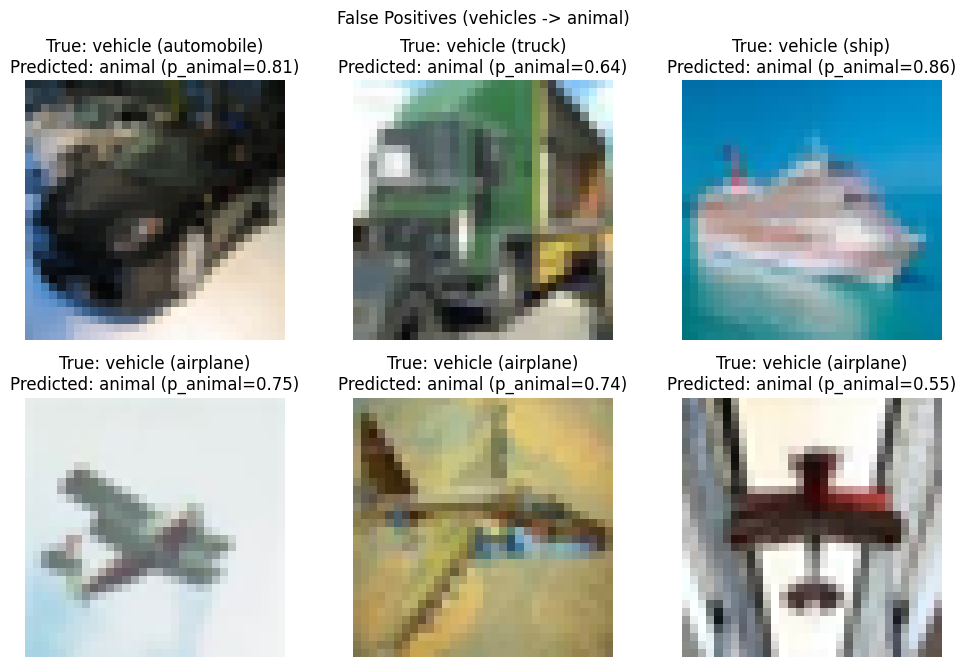

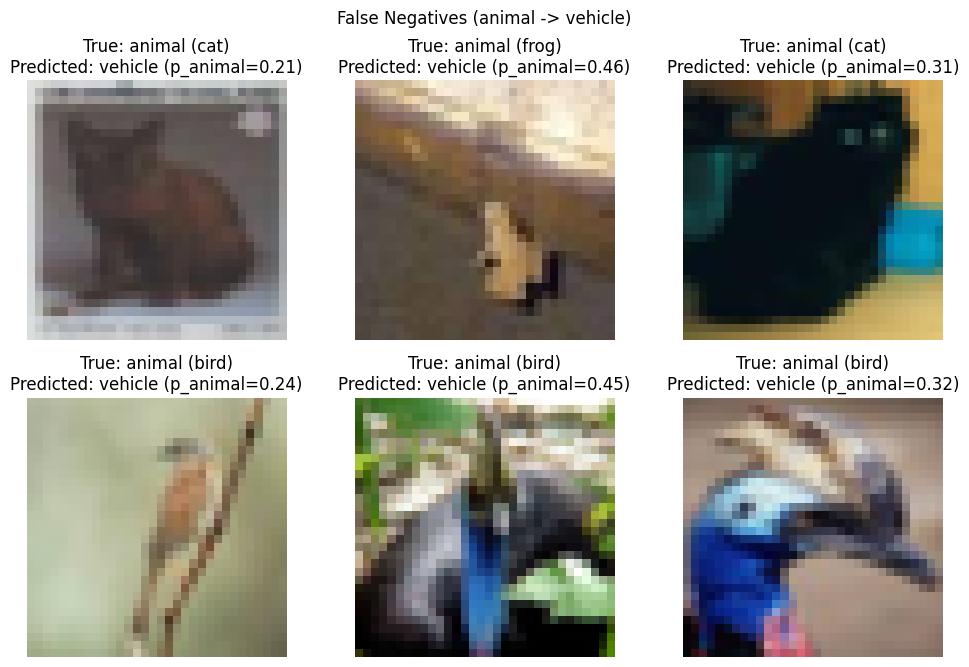

In [ ]:
fp_indexes = np.where((y_test == 0) & (y_test_pred_bin == 1))[0] # False positive indexes (vehicle misclassified as animal)
fn_indexes = np.where((y_test == 1) & (y_test_pred_bin == 0))[0] # False negative indexes (animal misclassified as vehicle)

def show_misclassified_examples(
  indexes,
  x_raw,
  y_true_bin,
  y_true_original,
  y_pred_bin,
  y_pred_prob,
  n_samples = 6,
  title_prefix = "Error",
):
  # Random choice within indexes
  selected = np.random.choice(indexes, size = n_samples, replace = False)

  plt.figure(figsize = (10, 10))

  for i, idx in enumerate(selected):

    img = x_raw[idx]
    true_bin = y_true_bin[idx]
    true_original = y_true_original[idx]
    pred_bin = y_pred_bin[idx]
    prob = y_pred_prob[idx]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

    true_label_name = CLASSES[true_original]
    true_macro = "animal" if true_bin == 1 else "vehicle"
    pred_macro = "animal" if pred_bin == 1 else "vehicle"

    plt.title(
      f"True: {true_macro} ({true_label_name})\n"
      f"Predicted: {pred_macro} (p_animal={prob:.2f})"
    )

  plt.suptitle(title_prefix)
  plt.tight_layout()
  plt.show()

# Show vehicle misclassified as animal
show_misclassified_examples(
  indexes = fp_indexes,
  x_raw = x_test_raw,
  y_true_bin = y_test,
  y_true_original = y_test_flat,
  y_pred_bin = y_test_pred_bin,
  y_pred_prob = y_test_pred_prob,
  title_prefix = "False Positives (vehicles -> animal)",
)

# Show animal misclassified as vehicle
show_misclassified_examples(
  indexes = fn_indexes,
  x_raw = x_test_raw,
  y_true_bin = y_test,
  y_true_original = y_test_flat,
  y_pred_bin = y_test_pred_bin,
  y_pred_prob = y_test_pred_prob,
  title_prefix = "False Negatives (animal -> vehicle)",
)

Effettivamente noto che immagini del genere:

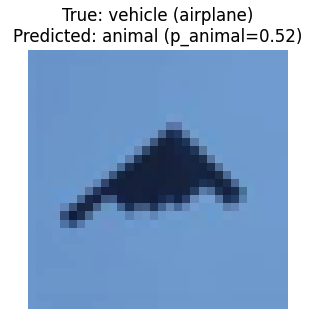

Possono indurre il modello a classificare tale aereo come uccello.

Allo stesso modo immagini con sfondi naturalistici come:

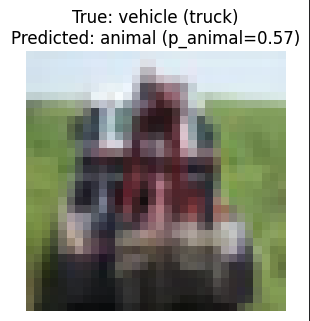

Possono indurre il modello a predirre animale.

Verifichiamo qualche altra immagine di aereo classificata come falso positivo:

N. esempi etichettati come 'airplane': 1000
N. errori 'airplane': 199


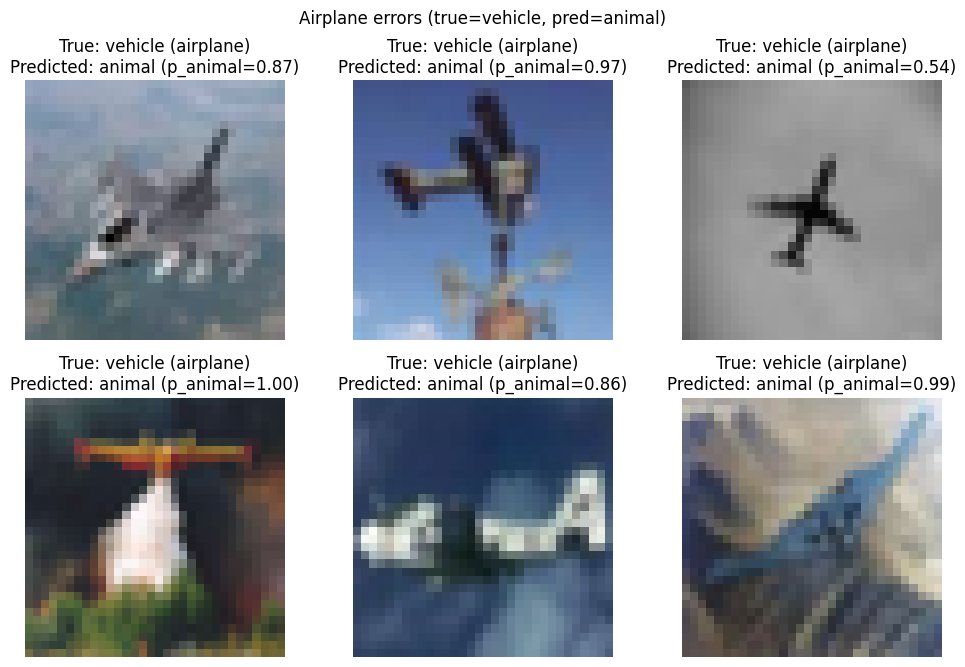

In [ ]:
airplane_indexes = np.where(y_test_flat == 0)[0] # 0 = airplane
airplane_error_indexes = np.where((y_test_flat == 0) & (y_test != y_test_pred_bin))[0]

print("N. esempi etichettati come 'airplane':", len(airplane_indexes))
print("N. errori 'airplane':", len(airplane_error_indexes))

show_misclassified_examples(
  indexes = airplane_error_indexes,
  x_raw = x_test_raw,
  y_true_bin = y_test,
  y_true_original = y_test_flat,
  y_pred_bin = y_test_pred_bin,
  y_pred_prob = y_test_pred_prob,
  title_prefix = "Airplane errors (true=vehicle, pred=animal)"
)

Confermo che casi come questi non sono sicuramente facili da gestire per il modello:

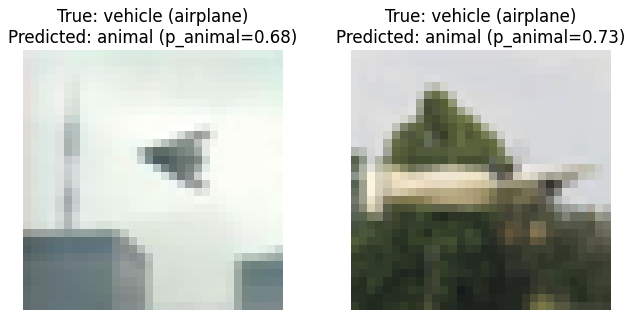

Tra le potenziali migliorie al modello potremmo valutare:
- Data augmentation mirata sulla classe `airplane` per rendere più robusto il modello a tali oggetti.
- Test con diversi valori di soglia: potremmo ad esempio alzare la tolleranza nel classificare le immagini in animali portando la soglia da `0.5` a `0.6`. Molti dei veicoli classificati erroneamente si trovano proprio sul range `0.5-0.6` di probabilità.
- Modificare in generale in qualsiasi modo la struttura della rete e gli iperparametri, ad esempio sbloccando più layer per l'addestramento.

## 4. Risultato Finale

In conclusione:
- Il modello è una rete neurale convoluzionale binaria basata su **MobileNetV2** (rete pre-addestrata su **ImageNet**) e adattata per distinguere tra veicoli e animali nel dataset **CIFAR-10**.
- Abbiamo raggiunto circa il 90% di accuratezza complessiva sul test e una precisione più alta per la classe `animal`. In ottica applicativa questo significa che il modello privilegia un po’ di più la sensibilità verso gli animali a discapito di qualche falso positivo in più sui veicoli, scelta probabilmente accettabile in un contesto di sicurezza stradale.
- La principale difficoltà è nella classe `airplane`, con un numero significativo di aerei classificati come `animal` come visto in precedenza.

---

Potenziali limitazioni e miglioramenti:
- Il modello potrebbe soffrire quando l’oggetto è piccolo o quando lo sfondo domina l’immagine e con una risoluzione di `32x32` tale problema è un problema intrinseco, mitigato solo in parte dal transfer learning.
- Per le classi problematiche *data augmentation* e *over-sampling* potrebbero aiutare.
- Qualsiasi eventuale modifica strutturale alla rete e agli iperparametri potrebbero ugualmente aiutare.